In [3]:
#Parte 1: Extracción de Datos desde la API de Codeforces
#Carga las librerías necesarias.

#Hace una solicitud al endpoint contest.list de Codeforces.

#Convierte la respuesta en un DataFrame.

#Filtra los concursos que se realizaron entre julio y diciembre de 2024, y cuyo nombre contiene “Hello”, “Round” o “Good Bye”.

#Muestra los concursos seleccionados para trabajar con ellos en las siguientes etapas.
#-----------------------------------------------------------------------------------------------------------------------------#    
# Importamos las librerías necesarias
import requests
import pandas as pd
from datetime import datetime

# Esta función convierte un timestamp a una fecha legible
def timestamp_to_date(timestamp):
    return datetime.utcfromtimestamp(timestamp)

# 1. Obtenemos la lista de concursos desde el endpoint contest.list
url_contests = "https://codeforces.com/api/contest.list"
response = requests.get(url_contests)
contests_data = response.json()

# Verificamos que la respuesta haya sido exitosa
assert contests_data['status'] == 'OK', "No se pudo obtener la lista de concursos"

# Convertimos los datos a un DataFrame para filtrarlos fácilmente
df_contests = pd.DataFrame(contests_data['result'])

# Convertimos los timestamps a fechas legibles
df_contests['startTime'] = df_contests['startTimeSeconds'].apply(timestamp_to_date)

# Filtramos los concursos por:
# - Fechas entre julio y diciembre 2024
# - Nombre que contenga 'Hello', 'Round' o 'Good Bye'
df_contests_filtered = df_contests[
    (df_contests['startTime'] >= datetime(2024, 7, 1)) &
    (df_contests['startTime'] <= datetime(2024, 12, 31)) &
    (df_contests['name'].str.contains('Hello|Round|Good Bye', case=False, na=False))
].copy()

# Mostramos los concursos seleccionados
print("Concursos seleccionados:")
display(df_contests_filtered[['id', 'name', 'startTime']])

Concursos seleccionados:


,id,name,startTime
48,2053,Good Bye 2024: 2025 is NEAR,2024-12-28 14:35:00
49,2043,Educational Codeforces Round 173 (Rated for Di...,2024-12-24 14:35:00
51,2051,Codeforces Round 995 (Div. 3),2024-12-22 14:35:00
52,2049,Codeforces Round 994 (Div. 2),2024-12-20 14:35:00
53,2048,Codeforces Global Round 28,2024-12-19 14:35:00
54,2044,Codeforces Round 993 (Div. 4),2024-12-15 14:35:00
56,2040,Codeforces Round 992 (Div. 2),2024-12-08 14:35:00
57,2050,Codeforces Round 991 (Div. 3),2024-12-05 14:35:00
58,2046,Codeforces Round 990 (Div. 1),2024-12-03 06:25:00
59,2047,Codeforces Round 990 (Div. 2),2024-12-03 06:25:00


In [5]:
#Parte 2: Extracción de Datos por Concurso
import time

# Definimos funciones para cada endpoint

# 1. Obtener standings y problemas
def get_standings(contest_id):
    url = f"https://codeforces.com/api/contest.standings?contestId={contest_id}&from=1&count=5000"
    res = requests.get(url)
    data = res.json()
    if data['status'] == 'OK':
        return data['result']
    return None

# 2. Obtener submissions
def get_submissions(contest_id):
    url = f"https://codeforces.com/api/contest.status?contestId={contest_id}"
    res = requests.get(url)
    data = res.json()
    if data['status'] == 'OK':
        return data['result']
    return None

# 3. Obtener cambios de rating
def get_rating_changes(contest_id):
    url = f"https://codeforces.com/api/contest.ratingChanges?contestId={contest_id}"
    res = requests.get(url)
    data = res.json()
    if data['status'] == 'OK':
        return data['result']
    return None

# 4. Obtener usuarios calificados (solo una vez)
def get_rated_users():
    url = "https://codeforces.com/api/user.ratedList?activeOnly=false"
    res = requests.get(url)
    data = res.json()
    if data['status'] == 'OK':
        return data['result']
    return None

# Creamos un diccionario para almacenar toda la información
contest_details = {}

# Iteramos sobre los concursos filtrados anteriormente
for _, row in df_contests_filtered.iterrows():
    contest_id = row['id']
    print(f"📥 Extrayendo datos para el concurso: {row['name']} (ID: {contest_id})")

    contest_details[contest_id] = {
        'name': row['name'],
        'start_time': row['startTime'],
        'standings': get_standings(contest_id),
        'submissions': get_submissions(contest_id),
        'rating_changes': get_rating_changes(contest_id)
    }
    
    # Esperamos 1 segundo entre llamadas para no sobrecargar la API
    time.sleep(1)

# Obtenemos la lista completa de usuarios calificados (solo una vez)
rated_users = get_rated_users()

print("✅ Extracción completa de todos los concursos.")

📥 Extrayendo datos para el concurso: Good Bye 2024: 2025 is NEAR (ID: 2053)
📥 Extrayendo datos para el concurso: Educational Codeforces Round 173 (Rated for Div. 2) (ID: 2043)
📥 Extrayendo datos para el concurso: Codeforces Round 995 (Div. 3) (ID: 2051)
📥 Extrayendo datos para el concurso: Codeforces Round 994 (Div. 2) (ID: 2049)
📥 Extrayendo datos para el concurso: Codeforces Global Round 28 (ID: 2048)
📥 Extrayendo datos para el concurso: Codeforces Round 993 (Div. 4) (ID: 2044)
📥 Extrayendo datos para el concurso: Codeforces Round 992 (Div. 2) (ID: 2040)
📥 Extrayendo datos para el concurso: Codeforces Round 991 (Div. 3) (ID: 2050)
📥 Extrayendo datos para el concurso: Codeforces Round 990 (Div. 1) (ID: 2046)
📥 Extrayendo datos para el concurso: Codeforces Round 990 (Div. 2) (ID: 2047)
📥 Extrayendo datos para el concurso: Educational Codeforces Round 172 (Rated for Div. 2) (ID: 2042)
📥 Extrayendo datos para el concurso: Rayan Programming Contest 2024 - Selection (Codeforces Round 989, 

Link para la carpeta con los archivos csv descargados:
https://drive.google.com/drive/folders/1NzMFkL1a1KvoV67B9lratY2uCsLblTyV?usp=sharing

#Código para guardar los archivos .csv por concurso
import os

# Creamos una carpeta para almacenar los CSVs
base_folder = "codeforces_data"
os.makedirs(base_folder, exist_ok=True)

for contest_id, data in contest_details.items():
    folder_name = os.path.join(base_folder, f"contest_{contest_id}")
    os.makedirs(folder_name, exist_ok=True)

    # Guardamos standings (solo rows, no problems)
    if data['standings'] and 'rows' in data['standings']:
        df_standings = pd.json_normalize(data['standings']['rows'])
        df_standings.to_csv(os.path.join(folder_name, "standings.csv"), index=False)

    # Guardamos submissions
    if data['submissions']:
        df_submissions = pd.json_normalize(data['submissions'])
        df_submissions.to_csv(os.path.join(folder_name, "submissions.csv"), index=False)

    # Guardamos cambios de rating
    if data['rating_changes']:
        df_rating = pd.DataFrame(data['rating_changes'])
        df_rating.to_csv(os.path.join(folder_name, "rating_changes.csv"), index=False)

# También exportamos la lista de usuarios calificados
if rated_users:
    df_users = pd.DataFrame(rated_users)
    df_users.to_csv(os.path.join(base_folder, "rated_users.csv"), index=False)

print("✅ Archivos CSV guardados con éxito.")

## Parte 3: Descripción del Dataset
## 📄 Descripción del Dataset

### 🔗 Endpoints de la API utilizados:

- `contest.list`: Lista de todos los concursos públicos en Codeforces.
- `contest.standings`: Información sobre los problemas de un concurso y la clasificación de los usuarios.
- `contest.status`: Todas las submissions de un concurso.
- `contest.ratingChanges`: Cambios de rating de los usuarios después del concurso.
- `user.ratedList`: Lista de todos los usuarios con rating en Codeforces.

### 🧱 Estructura del dataset

Para cada concurso se extrajeron tres tablas:

1. **Standings (`standings.csv`)**
   - `party.members[0].handle`: Usuario.
   - `problemResults`: Lista con información sobre cada problema (puntos, tiempo, etc.).
   - `rank`, `points`, `successfulHackCount`, etc.

2. **Submissions (`submissions.csv`)**
   - `id`: ID de la submission.
   - `creationTimeSeconds`: Fecha y hora de envío (en timestamp).
   - `relativeTimeSeconds`: Tiempo desde el inicio del concurso.
   - `verdict`: Resultado de la solución (OK, Wrong Answer, etc.).
   - `programmingLanguage`: Lenguaje usado.
   - `problem.index` y `problem.rating`: Información del problema resuelto.

3. **Rating Changes (`rating_changes.csv`)**
   - `handle`: Usuario.
   - `oldRating`, `newRating`: Puntos antes y después del concurso.
   - `rank`: Posición en el concurso.

4. **Usuarios (`rated_users.csv`)**
   - `handle`: Nombre del usuario.
   - `country`, `city`, `rating`, `maxRating`, etc.

### 📌 Variables clave para el análisis posterior

- `finished_n`: Si el usuario resolvió el problema `n`.
- `n_language`: Lenguaje usado para resolver el problema `n`.
- `relative_time_n`: Tiempo desde el inicio del concurso hasta la solución del problema `n`.
- `time_to_answer_n`: Diferencia de tiempo entre problemas resueltos.
- `rating_n`: Dificultad del problema.
- `rating_achieved`: Suma de los ratings de los problemas resueltos por el usuario.
- `contest_name`, `contest_start_time`: Contexto del concurso.
- `country`, `city`, `rating`, `max_rating`: Información del perfil del usuario.

In [13]:
# Parte 4: Código para limpieza y creación de variables
from collections import defaultdict
from tqdm import tqdm
import pandas as pd

# Crear diccionario para acceder fácilmente a los datos de cada usuario
# Esto evita tener que buscar a cada usuario en la lista de rated_users una y otra vez
users_dict = {user['handle']: user for user in rated_users}

# Estructura para almacenar todo el dataset limpio
final_data = []

# Recorremos cada concurso
for contest_id, data in tqdm(contest_details.items()):
    contest_name = data['name']
    contest_start = data['standings']['contest']['startTimeSeconds']
    problems = data['standings']['problems']
    
    # Crear diccionario de problemas (para acceder por problem.index)
    problem_info = {p['index']: p for p in problems}
    
    # Creamos un mapeo de handle -> cambios de rating
    ratings = {r['handle']: r for r in data.get('rating_changes', [])}
    
    # Agrupar submissions por usuario y problema
    submissions_by_user = defaultdict(lambda: defaultdict(list))
    for sub in data['submissions']:
        if 'author' in sub and 'members' in sub['author']:
            handle = sub['author']['members'][0]['handle']
            problem_index = sub['problem']['index']
            submissions_by_user[handle][problem_index].append(sub)

    # Procesamos cada fila del standings (un usuario)
    for row in data['standings']['rows']:
        handle = row['party']['members'][0]['handle']
        user_data = {
            'author_handle': handle,
            'contest_id': contest_id,
            'contest_name': contest_name,
            'contest_start_time': contest_start,
        }

        # Añadir país, ciudad, rating actual y máximo (si tenemos)
        if handle in users_dict:
            user = users_dict[handle]
            user_data.update({
                'country': user.get('country'),
                'city': user.get('city'),
                'rating': user.get('rating'),
                'max_rating': user.get('maxRating'),
            })

        # Añadir rating_achieved
        rating_change = ratings.get(handle)
        if rating_change:
            user_data['rating_achieved'] = rating_change['newRating']
        else:
            user_data['rating_achieved'] = None

        # Variables por problema
        total_rating = 0
        prev_time = 0
        for i, prob in enumerate(problems, 1):
            p_index = prob['index']
            p_rating = prob.get('rating')
            user_data[f'rating_{i}'] = p_rating

            # Revisamos si el usuario envió un "OK" para este problema
            subs = submissions_by_user[handle].get(p_index, [])
            solved = False
            min_time = None
            lang = None
            for sub in subs:
                if sub.get('verdict') == 'OK':
                    solved = True
                    if min_time is None or sub['relativeTimeSeconds'] < min_time:
                        min_time = sub['relativeTimeSeconds']
                        lang = sub.get('programmingLanguage')
            user_data[f'finished_{i}'] = solved
            user_data[f'relative_time_{i}'] = min_time
            user_data[f'{i}_language'] = lang

            # Sumar rating logrado
            if solved and p_rating:
                total_rating += p_rating

            # Calcular tiempo entre respuestas (si hay min_time)
            if min_time is not None:
                user_data[f'time_to_answer_{i}'] = min_time - prev_time
                prev_time = min_time
            else:
                user_data[f'time_to_answer_{i}'] = None

        user_data['rating_achieved'] = total_rating
        final_data.append(user_data)

# Convertimos a DataFrame
df_final = pd.DataFrame(final_data)

print(f"✅ Dataset final con {df_final.shape[0]} filas y {df_final.shape[1]} columnas.")
df_final.head()

100%|██████████| 57/57 [02:19<00:00,  2.45s/it]


✅ Dataset final con 264595 filas y 64 columnas.


,author_handle,contest_id,contest_name,contest_start_time,country,city,rating,max_rating,rating_achieved,rating_1,...,rating_10,finished_10,relative_time_10,10_language,time_to_answer_10,rating_11,finished_11,relative_time_11,11_language,time_to_answer_11
0,jiangly,2053,Good Bye 2024: 2025 is NEAR,1735396500,China,Chongqing,3710.0,4039.0,22900,800,...,3500.0,True,2.147484e+09,"C++23 (GCC 14-64, msys2)",2.147479e+09,NaN,NaN,NaN,NaN,NaN
1,ecnerwala,2053,Good Bye 2024: 2025 is NEAR,1735396500,United States,Cupertino,3627.0,3668.0,15900,800,...,3500.0,False,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN
2,Benq,2053,Good Bye 2024: 2025 is NEAR,1735396500,United States,Princeton,3539.0,3833.0,22900,800,...,3500.0,True,2.147484e+09,"C++23 (GCC 14-64, msys2)",2.147479e+09,NaN,NaN,NaN,NaN,NaN
3,Egor,2053,Good Bye 2024: 2025 is NEAR,1735396500,Germany,Augsburg,2937.0,3235.0,16000,800,...,3500.0,False,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN
4,Radewoosh,2053,Good Bye 2024: 2025 is NEAR,1735396500,Poland,Warsaw,3463.0,3759.0,19400,800,...,3500.0,False,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN


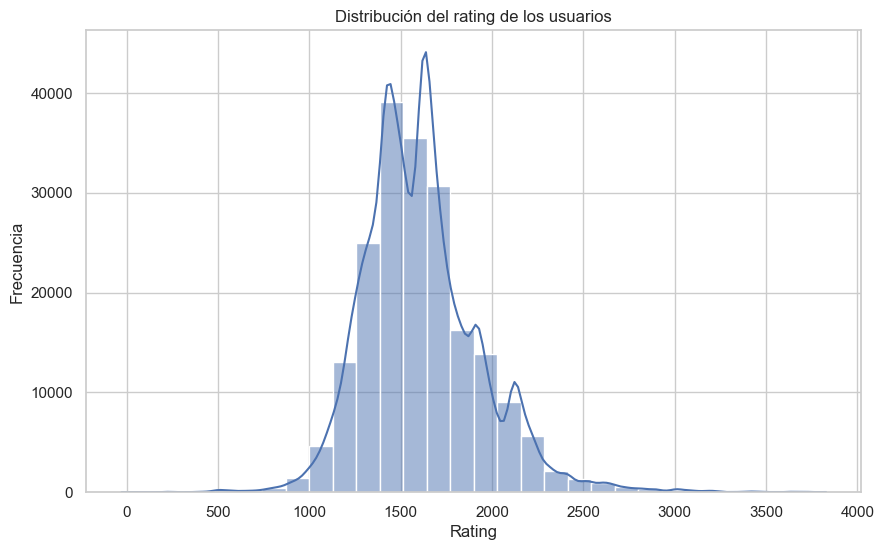

C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_30260\767654638.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


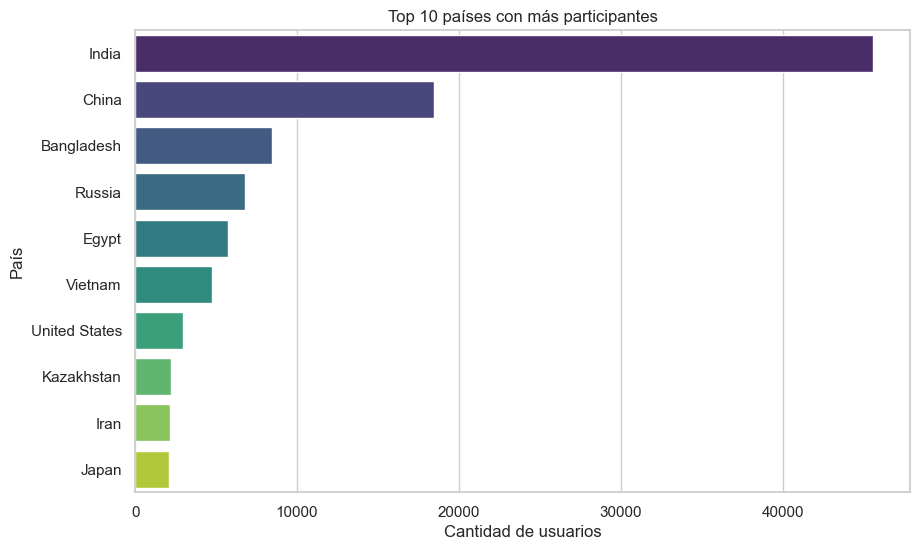

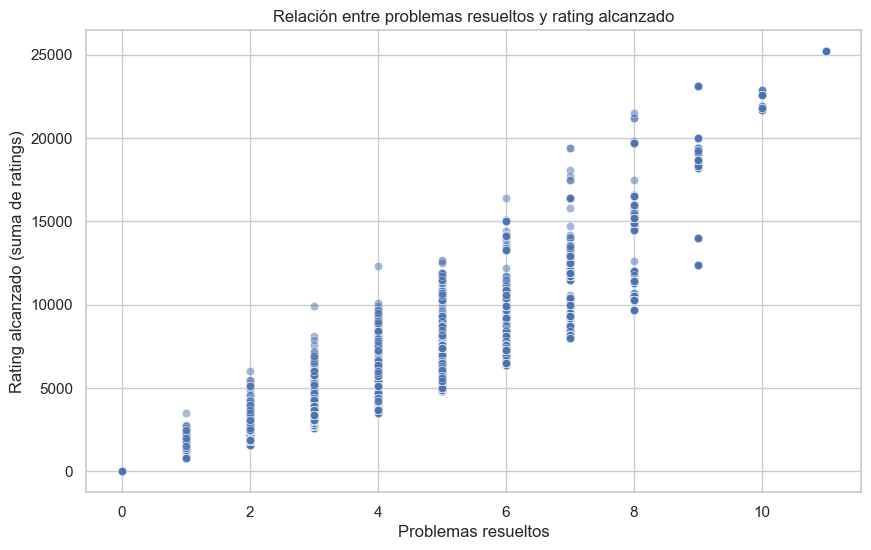

C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_30260\767654638.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=language_counts.values, y=language_counts.index, palette='coolwarm')


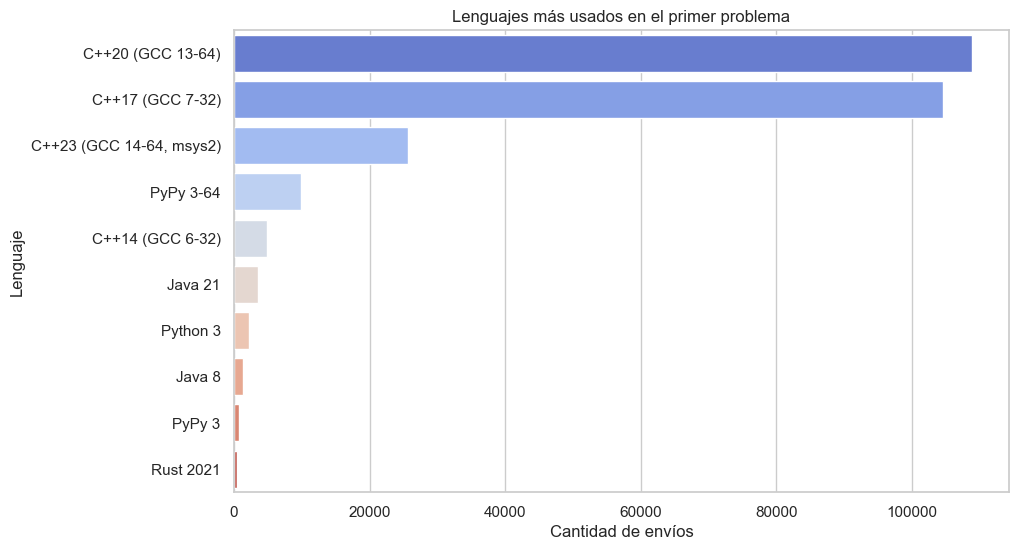

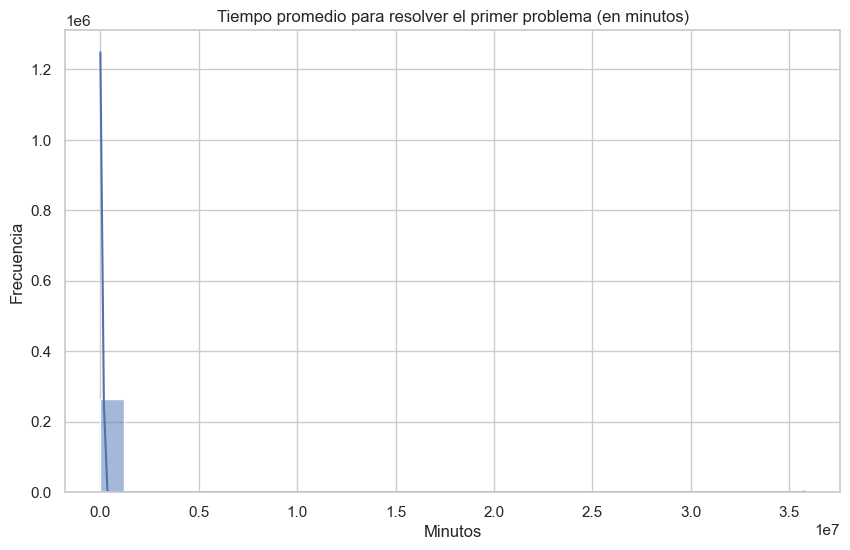

In [15]:
#Parte 5: Análisis exploratorio de datos (EDA) con visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo general para los gráficos
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# --- 1. Distribución del rating de usuarios
plt.figure()
sns.histplot(df_final['rating'].dropna(), bins=30, kde=True)
plt.title('Distribución del rating de los usuarios')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')
plt.show()

# --- 2. Top 10 países con más participantes
plt.figure()
top_countries = df_final['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 países con más participantes')
plt.xlabel('Cantidad de usuarios')
plt.ylabel('País')
plt.show()

# --- 3. Relación entre problemas resueltos y rating alcanzado
df_final['problems_solved'] = df_final[[col for col in df_final.columns if col.startswith('finished_')]].sum(axis=1)

plt.figure()
sns.scatterplot(data=df_final, x='problems_solved', y='rating_achieved', alpha=0.5)
plt.title('Relación entre problemas resueltos y rating alcanzado')
plt.xlabel('Problemas resueltos')
plt.ylabel('Rating alcanzado (suma de ratings)')
plt.show()

# --- 4. Lenguajes de programación más usados (en el primer problema)
plt.figure()
language_counts = df_final['1_language'].value_counts().head(10)
sns.barplot(x=language_counts.values, y=language_counts.index, palette='coolwarm')
plt.title('Lenguajes más usados en el primer problema')
plt.xlabel('Cantidad de envíos')
plt.ylabel('Lenguaje')
plt.show()

# --- 5. Tiempo promedio para resolver el primer problema
plt.figure()
sns.histplot(df_final['time_to_answer_1'].dropna() / 60, bins=30, kde=True)  # en minutos
plt.title('Tiempo promedio para resolver el primer problema (en minutos)')
plt.xlabel('Minutos')
plt.ylabel('Frecuencia')
plt.show()
